In [4]:
! pip install label-studio

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached attrs-25.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached lxml-5.4.0-cp311-cp311-win_amd64.whl.metadata (3.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached pydantic-2.11.5-py3-none-any.whl.metadata (67 kB)
  Using cached ujson-5.10.0-cp311-cp311-win_amd64.whl.metadata (9.5 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached 

  DEPRECATION: Building 'attr' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'attr'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'drf-flex-fields' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'drf-flex-fields'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'drf-generators' using the legacy setup.py bdist_w

In [5]:
! label-studio start

^C



0: 384x640 1 nombres, 2 numero_cedulas, 44.6ms
Speed: 0.9ms preprocess, 44.6ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


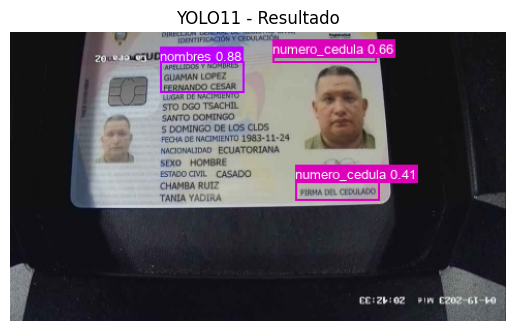

In [7]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

# Cargar el modelo YOLO (puede ser 'yolov8n.pt' o tu modelo personalizado)
model = YOLO("E:/Users/Documents/Trabajo/MiCasitaCIDetection/best.pt")  # Cambia por "runs/detect/train/weights/best.pt"

# Tipo de fuente
SOURCE_TYPE = "image"  # Opciones: "image"
SOURCE_PATH = "E:/Users/Documents/Trabajo/Cedulas/imagenes_cedula_peq/Cedula_Guayaquil/ImagenCedula_02C3Ivf.jpg"  # Ruta de la imagen

if SOURCE_TYPE == "image":
    # Cargar imagen con PIL
    image = Image.open(SOURCE_PATH).convert("RGB").rotate(180)

    # Realizar inferencia
    results = model(image)

    # Mostrar resultados usando PIL
    for result in results:
        # result.plot() devuelve una imagen NumPy (BGR), la convertimos a RGB para PIL
        img_array = result.plot()[:, :, ::-1]
        result_image = Image.fromarray(img_array)

        # Mostrar usando matplotlib
        plt.imshow(result_image)
        plt.axis('off')
        plt.title("YOLO11 - Resultado")
        plt.show()


In [1]:
! pip uninstall  torchvision -y 
! pip install  torchvision  --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached https://download.pytorch.org/whl/cu128/torchvision-0.22.1%2Bcu128-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
Using cached https://download.pytorch.org/whl/cu128/torchvision-0.22.1%2Bcu128-cp311-cp311-win_amd64.whl (7.6 MB)


In [2]:
import os
import random
from pathlib import Path
import shutil

# Carpetas de origen
IMAGES_DIR = Path("E:/Users/Documents/Trabajo/Training_Cedulas2.0 (2)/Training_Cedulas2.0/images")
LABELS_DIR = Path("E:/Users/Documents/Trabajo/Training_Cedulas2.0 (2)/Training_Cedulas2.0/labels")

# Porcentajes de división
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

# Asegurarse de tener imágenes con su .txt correspondiente
image_files = sorted([f for f in IMAGES_DIR.glob("*.*") if f.suffix in ['.jpg', '.jpeg', '.png']])
valid_files = [f for f in image_files if (LABELS_DIR / f.with_suffix(".txt").name).exists()]

print(f"Total de imágenes válidas: {len(valid_files)}")

# Mezclar aleatoriamente
random.shuffle(valid_files)

# Separar
n = len(valid_files)
train_files = valid_files[:int(n * train_ratio)]
val_files = valid_files[int(n * train_ratio):int(n * (train_ratio + val_ratio))]
test_files = valid_files[int(n * (train_ratio + val_ratio)):]

splits = {
    "train": train_files,
    "val": val_files,
    "test": test_files,
}

# Crear carpetas destino
for split in splits:
    (IMAGES_DIR / split).mkdir(parents=True, exist_ok=True)
    (LABELS_DIR / split).mkdir(parents=True, exist_ok=True)

    for img_path in splits[split]:
        label_path = LABELS_DIR / img_path.with_suffix(".txt").name
        shutil.copy(img_path, IMAGES_DIR / split / img_path.name)
        shutil.copy(label_path, LABELS_DIR / split / label_path.name)

print("✅ División completada: train / val / test.")


Total de imágenes válidas: 2470
✅ División completada: train / val / test.


In [4]:
import torch
print(torch.cuda.is_available())  # ¿True?
print(torch.version.cuda)         # ¿"11.8", "12.1", etc?|
print(torch.cuda.get_device_name(0))  # ¿Detecta tu GPU?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
! pip show torchvision

True
12.8
NVIDIA GeForce RTX 4070 SUPER
Name: torchvision
Version: 0.22.1+cu128
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: C:\Users\jeff_\.conda\envs\trabajo\Lib\site-packages
Requires: numpy, pillow, torch
Required-by: ultralytics


In [6]:
from ultralytics import YOLO

# Cargar un modelo base (puedes cambiar a yolov8s.pt, yolov8m.pt, etc.)
model = YOLO("yolo11n-obb.pt")  # o "yolov8s.pt", o "yolov8n.yaml" para comenzar desde cero

# Entrenar el modelo
model.train(
    data="E:/Users/Documents/Trabajo/Training_Cedulas2.0 (2)/data.yaml",  # Ruta al archivo de configuración
    epochs=50,                 # Número de épocas
    imgsz=640,                 # Tamaño de entrada de imagen
    batch=16,                  # Tamaño del batch
    workers=4,                 # Núm. de workers para carga de datos
    device=0,                  # Usa la GPU 0; usa "cpu" para CPU
    name="yolo11_obb_custom",      # Nombre de la carpeta del experimento
    verbose=True,
)


Ultralytics 8.3.154  Python-3.11.13 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 12281MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:/Users/Documents/Trabajo/Training_Cedulas2.0 (2)/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11_obb_custom7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

train: Scanning E:\Users\Documents\Trabajo\Training_Cedulas2.0 (2)\dataset\labels\train... 1482 images, 2 backgrounds, 0 corrupt: 100%|██████████| 1482/1482 [00:02<00:00, 732.31it/s]

train: E:\Users\Documents\Trabajo\Training_Cedulas2.0 (2)\dataset\images\train\07db142a-ImagenCedula_1585.jpg: 1 duplicate labels removed
train: E:\Users\Documents\Trabajo\Training_Cedulas2.0 (2)\dataset\images\train\7fd88596-ImagenCedula_2249.jpg: 1 duplicate labels removed
train: E:\Users\Documents\Trabajo\Training_Cedulas2.0 (2)\dataset\images\train\ba8f57ae-ImagenCedula_920.jpg: 1 duplicate labels removed


train: New cache created: E:\Users\Documents\Trabajo\Training_Cedulas2.0 (2)\dataset\labels\train.cache
val: Fast image access  (ping: 0.10.0 ms, read: 6.99.4 MB/s, size: 156.3 KB)


val: Scanning E:\Users\Documents\Trabajo\Training_Cedulas2.0 (2)\dataset\labels\val... 494 images, 0 backgrounds, 0 corrupt: 100%|██████████| 494/494 [00:02<00:00, 215.25it/s]

...

       9/50      4.43G      1.002     0.7593      1.971         46        640: 100%|██████████| 93/93 [00:12<00:00,  7.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 31/31 [00:04<00:00,  6.33it/s]

                   all        494       1218      0.939      0.922      0.976      0.747



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      10/50      4.44G      1.002     0.7295      1.988         65        640:  86%|████████▌ | 80/93 [00:10<00:01,  7.30it/s]


KeyboardInterrupt: 